In [1]:
import sys
sys.path.append("/Users/azane/GitRepo/cities/docs/experimental_notebooks/dynsys")  # HACK
from labor_and_pop import *

In [2]:
employment_classes = ["agriculture", "knowledge", "healthcare"]
_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
colors = dict(zip(employment_classes, _colors))
fips_codes = [1001, 1005, 2001, 2003, 3005]

In [3]:
# Generate synthetic data from the model.

fdyns, initial_state = full_prior(employment_classes, fips_codes)

start_time = tnsr(0.0)
end_time = tnsr(30.0)
step_size = tnsr(0.1)
# noinspection PyTypeChecker
trajectory_times = torch.arange(start_time + step_size, end_time, step_size)

with LogTrajectory(trajectory_times) as traj:
    simulate(fdyns, initial_state, start_time, end_time, solver=TorchDiffEq(), method="dopri8")

# Build a dataset by subsampling the noisy_traj for all states.
noisy_traj = fdyns.observation(traj.trajectory)
data = State(**{f"{k}_obs": v[:, ::10] for k, v in noisy_traj.items()})
data_times = traj.times[::10]

In [11]:
def plot_traj(traj, fipsid, times=None, ax=None):
    if times is None:
        times = torch.arange(traj[list(traj.keys())[0]].shape[1])

    if ax is None:
        fig, ax = plt.subplots()
    ax.set_title(f"FIPS {fips_codes[fipsid]}")
    for k, v in traj.items():
        non_obs_k = k.split("_")[0]
        ax.plot(times, traj[k][fipsid], label=non_obs_k, color=colors[non_obs_k])

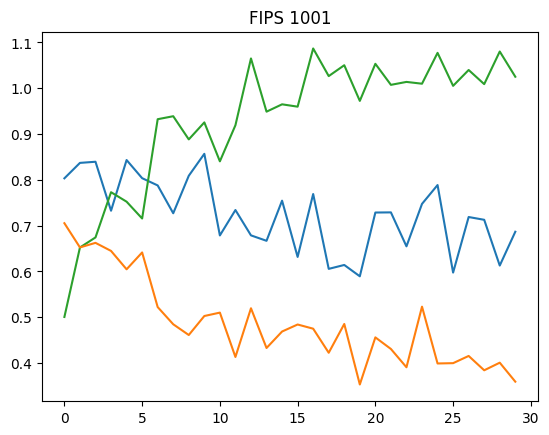

In [5]:
plot_traj(data, 0)

In [6]:
# Condition on stuff.
obs = condition(data=data)(fdyns.observation)

def conditioned_model():
    fdyns, initial_state = full_prior(employment_classes, fips_codes)

    with StaticBatchObservation(times=data_times, observation=obs):
        simulate(fdyns, initial_state, start_time, end_time, solver=TorchDiffEq())

with pyro.poutine.trace() as tr:
    conditioned_model()

guide, losses = run_svi_inference(conditioned_model, verbose=1, n_steps=1500, lr=1e-2)

[iteration 0001] loss: 2914.1111
[iteration 0002] loss: 3563.2812
[iteration 0003] loss: 3083.7383
[iteration 0004] loss: 3127.0969
[iteration 0005] loss: 3183.3843
[iteration 0006] loss: 2710.1372
[iteration 0007] loss: 2736.6218
[iteration 0008] loss: 2945.5811
[iteration 0009] loss: 2057.5928
[iteration 0010] loss: 2434.5088
[iteration 0011] loss: 2411.5002
[iteration 0012] loss: 2542.4221
[iteration 0013] loss: 2522.5269
[iteration 0014] loss: 2154.7036
[iteration 0015] loss: 1953.8451
[iteration 0016] loss: 2489.8062
[iteration 0017] loss: 2152.3679
[iteration 0018] loss: 1483.9539
[iteration 0019] loss: 1524.4395
[iteration 0020] loss: 1556.0074
[iteration 0021] loss: 1824.1072
[iteration 0022] loss: 1997.0062
[iteration 0023] loss: 1082.0121
[iteration 0024] loss: 1336.7375
[iteration 0025] loss: 1600.1379
[iteration 0026] loss: 1228.7903
[iteration 0027] loss: 969.6887
[iteration 0028] loss: 1425.1161
[iteration 0029] loss: 1497.9661
[iteration 0030] loss: 1543.6221
[iteration 

In [7]:
# Generate posterior mean predictives.
trajs = []
for i in range(300):
    # TODO use predictive so that it replays through the model.
    posterior_sample = guide()
    fdyns.fluxes = transform_county_fluxes(posterior_sample['county_flux'].squeeze(), 0.1)
    posterior_initial_state = State(**{
        k: posterior_sample[f"{k}0"] for k in employment_classes
    })

    with LogTrajectory(trajectory_times) as traj:
        simulate(fdyns, posterior_initial_state, start_time, end_time, solver=TorchDiffEq())

    trajs.append(traj.trajectory)

    print(f"{i:4d}", end="\r")

In [8]:
stacked_trajs = {k: torch.stack([t[k] for t in trajs]).detach() for k in traj.trajectory.keys()}
q05 = {k: torch.quantile(v, 0.05, dim=0) for k, v in stacked_trajs.items()}
q50 = {k: torch.quantile(v, 0.5, dim=0) for k, v in stacked_trajs.items()}
q95 = {k: torch.quantile(v, 0.95, dim=0) for k, v in stacked_trajs.items()}

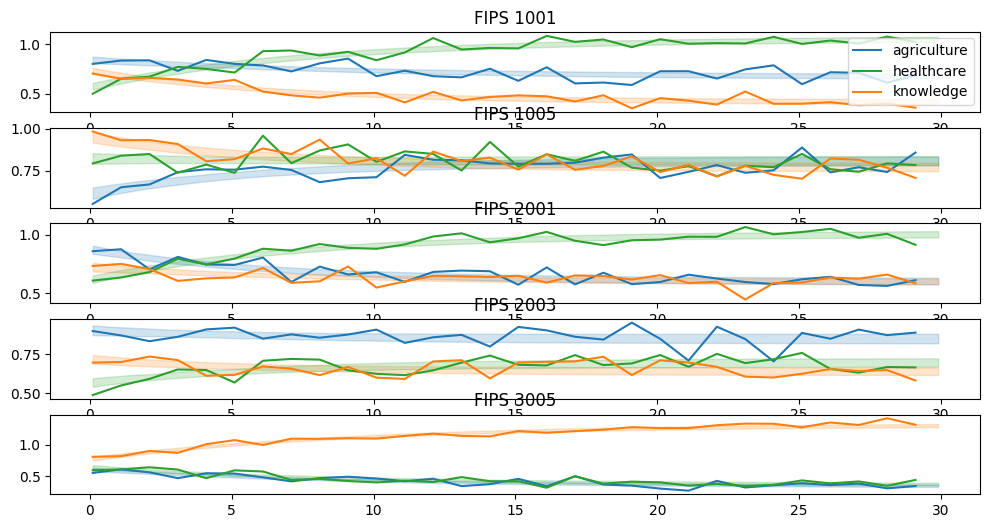

In [12]:
fig, axes = plt.subplots(len(fips_codes), 1, figsize=(12, 6))
xx = traj.times
for fipsid, ax in enumerate(axes):
    for k in employment_classes:
        ax.fill_between(xx, q05[k][fipsid], q95[k][fipsid], alpha=0.2, color=colors[k])
    plot_traj(data, times=data_times, fipsid=fipsid, ax=ax)
axes[0].legend()

# Hypothesis

Doing inference on dynamics shared across chunks of time, each with an inferred "initial (intermediate) conditions" would probably be a lot easier. We may be able to do some version of annealing where we start with small chunks, and slowly increase chunk size as inference proceeds. This would allow more of the data to inform the inference process at the same time.

More generally, blend reliance between the dynamics (hard, sensitive), and the state curves (easy). Anneal toward reliance on the dynamics.